In [1]:
import pyettj.ettj as ettj
import pandas as pd
from tqdm import tqdm
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

#1. Coleta dos Dados:
de = '13/05/2019'
ate ='18/05/2019'
datas = ettj.listar_dias_uteis(de, ate)

pyettj 0.3.4
Arquivo encontrado em: C:\Users\rrafa\Downloads\Feriados.csv
Carregando feriados do arquivo local...


In [5]:
def obter_dados_e_preparar_dataframe(datas, curva = 'DI x pré 252', vertices = None) -> pd.DataFrame:
    dados_historicos_taxas = pd.DataFrame()
    for dat in tqdm(datas):
        ano, mes, dia = dat.split("-")
        data = "/".join([dia, mes, ano])
        dados = ettj.get_ettj(data)
        dados_historicos_taxas = pd.concat([dados, dados_historicos_taxas])
    taxa_pre = dados_historicos_taxas[['Data', 'Dias Corridos', curva]].set_index('Data')
    taxa_pre.columns = ["Dias", curva]
    taxa_pre['colunas'] = taxa_pre["Dias"]

    taxa_pre = taxa_pre.pivot_table(values=curva, columns="colunas", index=taxa_pre.index)
    colunas_ordenadas = sorted(taxa_pre.columns)
    taxa_pre = taxa_pre[colunas_ordenadas]

    if vertices:
        taxa_pre = taxa_pre[[col for col in taxa_pre.columns if col in vertices]]
        return taxa_pre
    else:
        return taxa_pre.dropna(axis=1)

In [22]:
taxa_pre = obter_dados_e_preparar_dataframe(datas, curva = 'DI x pré 252')
taxa_pre

 20%|████████████████▊                                                                   | 1/5 [00:03<00:12,  3.02s/it]

Curvas capturadas em 3.02 segundos.


 40%|█████████████████████████████████▌                                                  | 2/5 [00:05<00:08,  2.99s/it]

Curvas capturadas em 2.97 segundos.


 60%|██████████████████████████████████████████████████▍                                 | 3/5 [00:09<00:06,  3.20s/it]

...

 80%|███████████████████████████████████████████████████████████████████▏                | 4/5 [00:12<00:03,  3.10s/it]

Curvas capturadas em 2.95 segundos.


100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:15<00:00,  3.07s/it]

Curvas capturadas em 2.97 segundos.


colunas,210,420,630,840,1050,2520
Data,,,,,,
13/05/2019,6.41000,6.56000,6.99000,7.38000,7.73000,8.81000
14/05/2019,6.40000,6.51000,6.92000,7.32000,7.63000,8.77000
15/05/2019,6.40000,6.52000,6.92000,7.32000,7.65000,8.82000
16/05/2019,6.43000,6.59000,7.01000,7.43000,7.75000,8.93000
17/05/2019,6.46000,6.70000,7.14000,7.57000,7.90000,9.13000


In [44]:
taxa_pre.to_excel('teste_pyettj.xlsx')

In [7]:
taxa_pre.columns

Index([210, 420, 630, 840, 1050, 2520], dtype='int64', name='colunas')

<Axes: xlabel='210', ylabel='Density'>

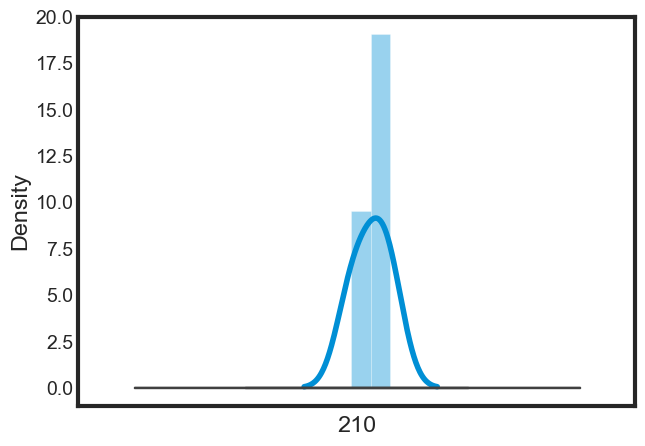

In [8]:
import seaborn as sns; sns.set_style("white")

HP = 2
choques_historicos_pre = taxa_pre.diff(HP).dropna()

sns.distplot(choques_historicos_pre[210])

sns.boxplot(data=choques_historicos_pre[210])

In [15]:
pontos_base_estresses_historicos_pre = pd.concat([
                                        choques_historicos_pre.quantile(0.99, interpolation="nearest"),
                                        choques_historicos_pre.quantile(1-0.99, interpolation="nearest")],
                                                 axis=1)*10_000 #em bps
pontos_base_estresses_historicos_pre.columns = ["Choques Positivos", "Choques Negativos"]
pontos_base_estresses_historicos_pre

,Choques Positivos,Choques Negativos
colunas,,
210,600.00000,-100.00000
420,1800.00000,-400.00000
630,2200.00000,-700.00000
840,2500.00000,-600.00000
1050,2500.00000,-800.00000
2520,3100.00000,100.00000


In [2]:
import pyettj.HJM as HJM

In [23]:
modelo = HJM.ModeloHJM(convencao_dias=252, verbose=1)

#sempre usar dias uteis conforme dados oriundos do pyettj acima
vertices_calibracao = [420, 840, 1050, 2520]

In [24]:
teste = taxa_pre.copy()

modelo.calibrar(teste, vertices_calibracao)
if modelo.calibrado:
    print(f"✅ Calibração concluída! {modelo}")

[HJM] Iniciando calibração...
colunas_df Index([0.8333333333333334, 1.6666666666666667, 2.5, 3.3333333333333335, 4.166666666666667, 10.0], dtype='float64')
colunas_existentes [np.float64(1.6666666666666667), np.float64(3.3333333333333335), np.float64(4.166666666666667), np.float64(10.0)]
[HJM] Número de componentes: 1
[HJM] Executando otimização...
[HJM] Calibração concluída com sucesso!
✅ Calibração concluída! ModeloHJM(convencao_dias=252, vertices=4, n_comp=1, status=calibrado)


In [27]:


data_choque = "2019-05-15"

resultado_pos = modelo.aplicar_choques(
    data_choque=data_choque,
    vertices_choques_dias=[21, 504, 252*10],
    choques_observados = np.array([-100, 0, 255])/10_000, #choque dos especialistas em bps
    hp_dias=2,
    retornar_detalhes=True
)

resultado_neg = modelo.aplicar_choques(
    data_choque=data_choque,
    vertices_choques_dias=[21, 504, 252*10],
    choques_observados = np.array([100, 0, -200])/10_000, #choque dos especialistas em bps
    hp_dias=2,
    retornar_detalhes=True
)

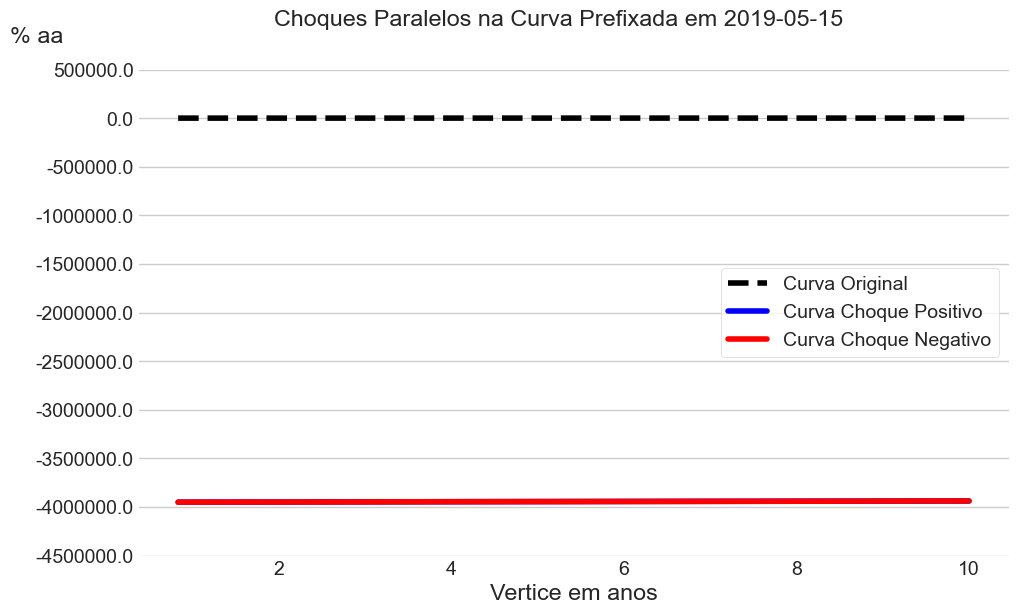

In [29]:
import matplotlib.pyplot as plt

resultado = resultado_neg['curva'][resultado_neg['curva'].columns[1:]]
resultado.columns = ["Curva Original", "Curva Choque Negativo"]
resultado = pd.concat([resultado, resultado_pos['curva'][resultado_pos['curva'].columns[2:]] ], axis=1).multiply(100)
resultado.columns = ["Curva Original", "Curva Choque Positivo", "Curva Choque Negativo"]

plt.figure(figsize=(10,6))
plt.plot(resultado[["Curva Original"]], 'k--')
plt.plot(resultado[["Curva Choque Positivo"]], 'b')
plt.plot(resultado[["Curva Choque Negativo"]], 'r')
plt.xlabel('Vertice em anos')
plt.ylabel('% aa\n', loc="top", rotation=0, labelpad=-20)
locs, vals = plt.yticks()
plt.yticks(locs, np.round(locs,1))
plt.suptitle(f'Choques Paralelos na Curva Prefixada em {data_choque}')
plt.legend(resultado.columns)
plt.box(False)
plt.grid(axis="y")
plt.show()

In [31]:
print("=== Análise de Componentes Principais ===")
print(modelo.pca)

print("=== Parâmetros Estimados ===")
print(modelo.parametros)

print("=== Resumo do Modelo ===")
resumo = modelo.resumo()
print(resumo)

print(f"Número de componentes: {modelo.num_componentes}")

# Vértices usados na calibração (em dias)
print(f"Vértices: {modelo.vertices_dias}")

=== Análise de Componentes Principais ===
      variação explicada (%)  soma acum. (%)
PC 1                98.67792        98.67792
PC 2                 0.93436        99.61228
PC 3                 0.38772       100.00000
PC 4                 0.00000       100.00000
=== Parâmetros Estimados ===
          fator 1
alpha -8550.17242
beta   5121.98651
gamma    -4.41752
delta    -1.10258
=== Resumo do Modelo ===
{'status': 'Calibrado', 'vertices_dias': [420, 840, 1050, 2520], 'vertices_ano': [1.6666666666666667, 3.3333333333333335, 4.166666666666667, 10.0], 'n_componentes': 1, 'convencao_dias': 252, 'variancia_explicada': 98.6779244766694, 'data_calibracao': '2026-03-17T18:02:08.064635'}
Número de componentes: 1
Vértices: [420, 840, 1050, 2520]
